<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1> ML & DL </h1></b></center>

<center><b><h1>Lab - 7</b></center>    
<pre>    

# Do all pre processing on diabetes csv

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


# Import diabetes.csv data ser using sklearn

In [44]:
df = pd.read_csv('diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,Diabetic
1,1,85,66,29,0,26.6,0.351,31,Non Diabetic
2,8,183,64,0,0,23.3,0.672,32,Diabetic
3,1,89,66,23,94,28.1,0.167,21,Non Diabetic
4,0,137,40,35,168,43.1,2.288,33,Diabetic
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,Non Diabetic
764,2,122,70,27,0,36.8,0.340,27,Non Diabetic
765,5,121,72,23,112,26.2,0.245,30,Non Diabetic
766,1,126,60,0,0,30.1,0.349,47,Diabetic


# Check the distribution of the target

In [45]:
print(df['Outcome'].value_counts())

Outcome
Non Diabetic    500
Diabetic        268
Name: count, dtype: int64


# Replace zeros with NaN for specific columns

In [46]:
df['Outcome'] = df['Outcome'].map({
    'Non Diabetic': 0,
    'Diabetic': 1
})

assert df['Outcome'].isna().sum() == 0


In [47]:
cols_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_to_fix] = df[cols_to_fix].replace(0, np.nan)

# Check for missing values

In [48]:
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

# Fill missing values with median

In [49]:
for col in cols_to_fix:
    df[col].fillna(df[col].median(), inplace=True)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_14516\2150678501.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_14516\2150678501.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

# Convert Targer data into interger code

# Visualize Distributions

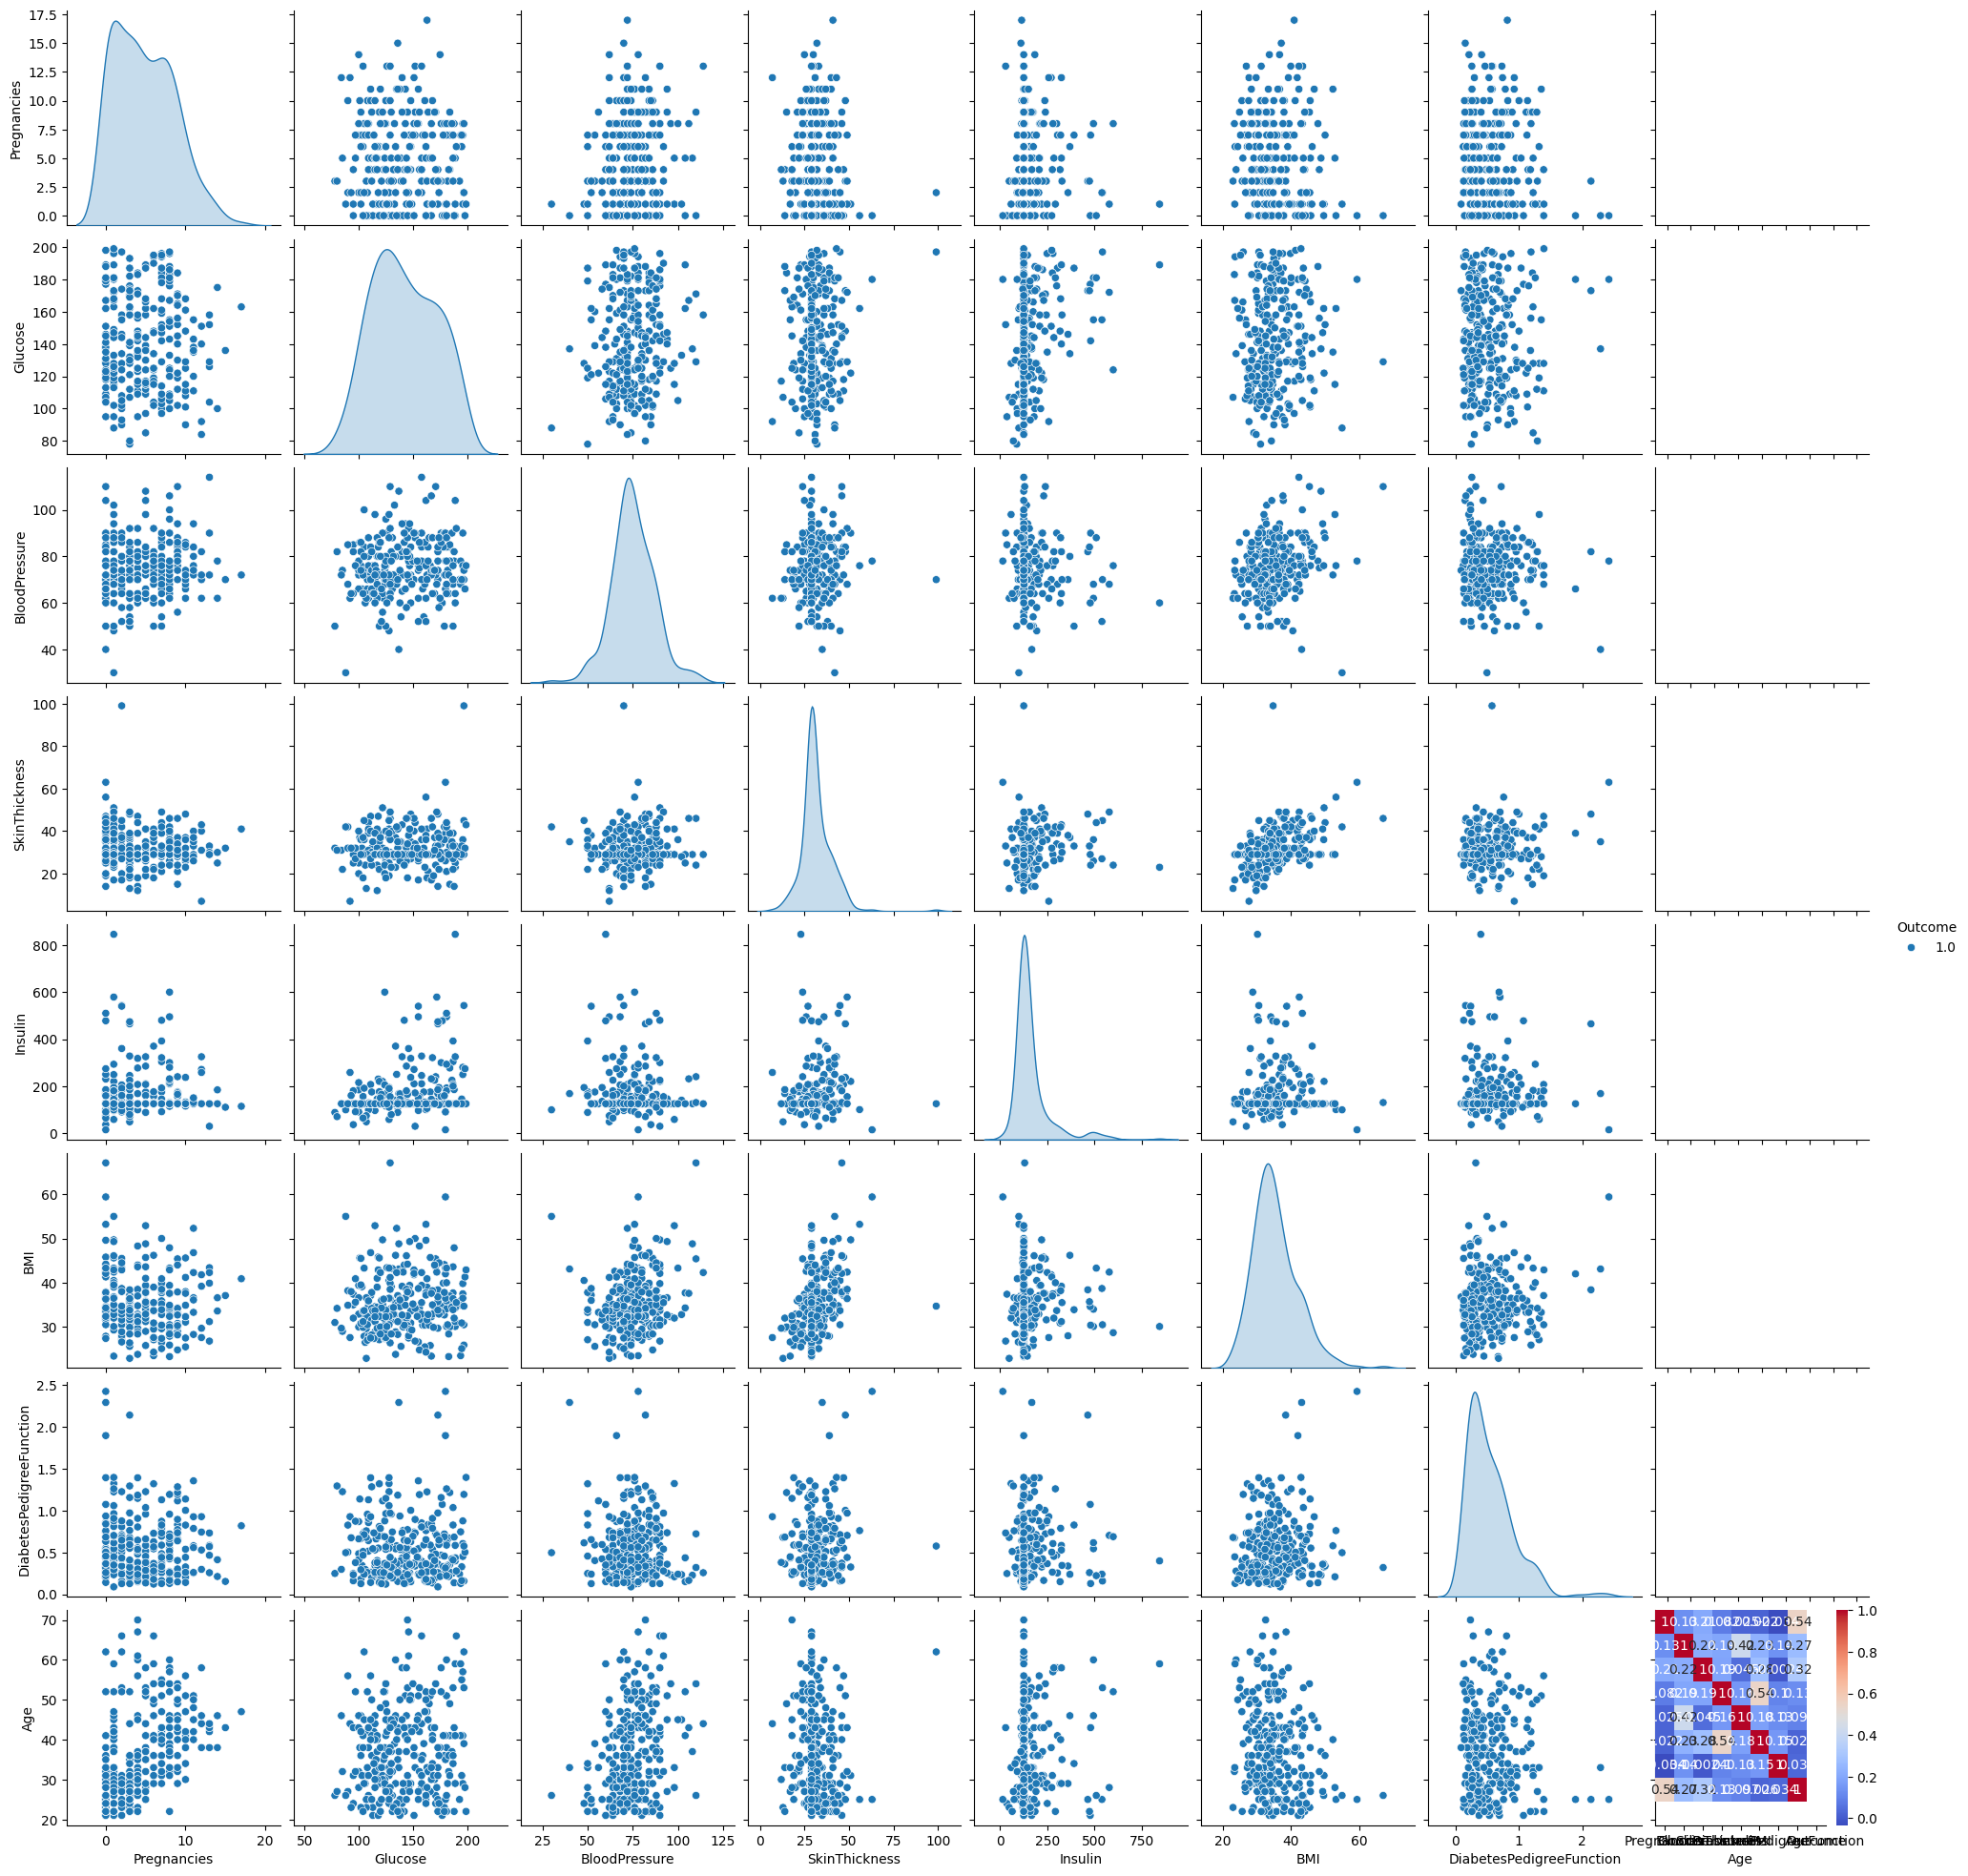

In [8]:
import seaborn as sns
sns.pairplot(df, hue='Outcome')
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

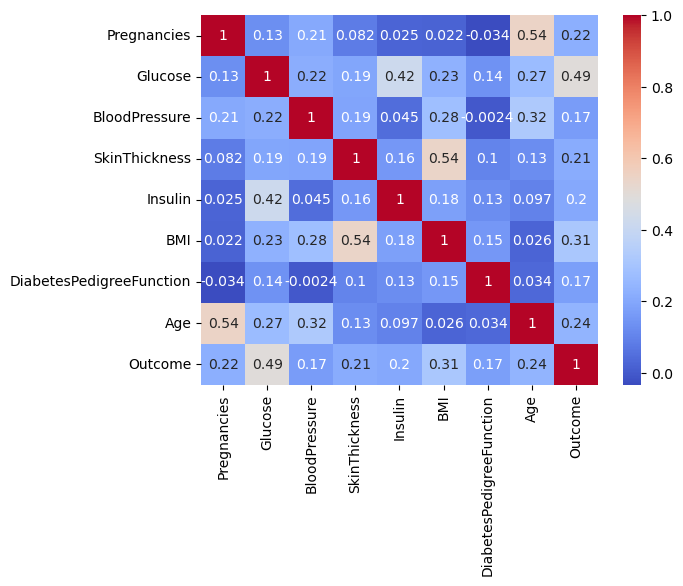

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0
764,2,122.0,70.0,27.0,125.0,36.8,0.340,27,0
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0
766,1,126.0,60.0,29.0,125.0,30.1,0.349,47,1


# Divide the data into input and output

In [51]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [52]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=1
)

In [55]:
assert np.isnan(X_train).sum() == 0
assert y_train.isna().sum() == 0

# import KNN Model

In [56]:
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)


KNeighborsClassifier()

# Convert all features into Z score

array([[ 0.63994726,  0.86604475, -0.03198993, ...,  0.16661938,
         0.46849198,  1.4259954 ],
       [-0.84488505, -1.20506583, -0.5283186 , ..., -0.85219976,
        -0.36506078, -0.19067191],
       [ 1.23388019,  2.01666174, -0.69376149, ..., -1.33250021,
         0.60439732, -0.10558415],
       ...,
       [ 0.3429808 , -0.02157407, -0.03198993, ..., -0.910418  ,
        -0.68519336, -0.27575966],
       [-0.84488505,  0.14279979, -1.02464727, ..., -0.34279019,
        -0.37110101,  1.17073215],
       [-0.84488505, -0.94206766, -0.19743282, ..., -0.29912651,
        -0.47378505, -0.87137393]])

# Splitting the dataset into the Training set and Test set

# Create KNN Model

# Fitting KNN   on dataset

KNeighborsClassifier()

0.7835497835497836

# Display classification_report

In [27]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,classification_report

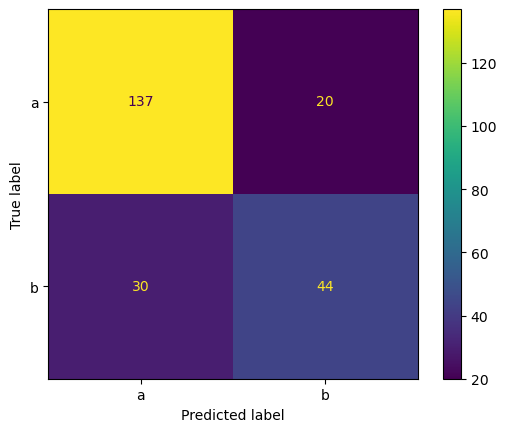

              precision    recall  f1-score   support

           0       0.82      0.87      0.85       157
           1       0.69      0.59      0.64        74

    accuracy                           0.78       231
   macro avg       0.75      0.73      0.74       231
weighted avg       0.78      0.78      0.78       231



# Use Cross Validation to find best hyperparameter for KNN

In [57]:
from sklearn.model_selection import cross_val_score

In [58]:
from sklearn.model_selection import KFold

In [59]:
k = KFold(n_splits=10)

0.7142857142857143
0.8051948051948052
0.7142857142857143
0.6753246753246753
0.7402597402597403
0.7532467532467533
0.7532467532467533
0.7922077922077922
0.6578947368421053
0.7368421052631579


array([0.71428571, 0.80519481, 0.71428571, 0.67532468, 0.74025974,
       0.75324675, 0.75324675, 0.79220779, 0.65789474, 0.73684211])

In [37]:
import numpy as np

In [40]:
x1 = np.arange(1,11).reshape(-1,1)

In [60]:
y1 = np.array([0,1,0,1,0,1,0,1,0,1])

In [61]:
x1

array([[ 1],
       [ 2],
       [ 3],
       [ 4],
       [ 5],
       [ 6],
       [ 7],
       [ 8],
       [ 9],
       [10]])

In [62]:
y1

array([0, 1, 0, 1, 0, 1, 0, 1, 0, 1])

In [63]:
for i,j in k.split(x1):
    print("<------>")
    print(x1[i])
    print(x1[j])
    x_train,x_test = x1[i],x1[j]
    y_train,y_test = y1[i],y1[j]
    

<------>
[[ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]]
[[1]]
<------>
[[ 1]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]]
[[2]]
<------>
[[ 1]
 [ 2]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]]
[[3]]
<------>
[[ 1]
 [ 2]
 [ 3]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]]
[[4]]
<------>
[[ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]]
[[5]]
<------>
[[ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 7]
 [ 8]
 [ 9]
 [10]]
[[6]]
<------>
[[ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 8]
 [ 9]
 [10]]
[[7]]
<------>
[[ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 9]
 [10]]
[[8]]
<------>
[[ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [10]]
[[9]]
<------>
[[1]
 [2]
 [3]
 [4]
 [5]
 [6]
 [7]
 [8]
 [9]]
[[10]]


In [38]:
parameters = {'n_neighbors':(1,2,3,4,5,6,7,8,9,10,11),'weights':('uniform', 'distance')}

In [39]:
from sklearn.model_selection import GridSearchCV

GridSearchCV(estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': (1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11),
                         'weights': ('uniform', 'distance')})

{'n_neighbors': 11, 'weights': 'uniform'}

0.7656650539003481

KNeighborsClassifier(n_neighbors=11)

{'mean_fit_time': array([0.0015532 , 0.00085506, 0.00057263, 0.00045662, 0.0004519 ,
        0.00045395, 0.00045438, 0.00045342, 0.00045295, 0.00045443,
        0.00045152, 0.00045686, 0.00045309, 0.00045485, 0.0004529 ,
        0.00045919, 0.00055366, 0.00052924, 0.00055528, 0.00051055,
        0.00046563, 0.00046191]),
 'std_fit_time': array([7.36628386e-04, 1.01100341e-04, 4.22888700e-05, 3.02105600e-06,
        2.65320353e-06, 5.67015323e-06, 2.43793927e-06, 4.53221114e-06,
        3.05101266e-06, 5.19073988e-06, 2.05317022e-06, 1.32894781e-05,
        4.12016002e-06, 3.22491425e-06, 1.09361123e-06, 1.48968690e-05,
        1.09285875e-04, 8.09783220e-05, 1.39654118e-04, 6.88277068e-05,
        4.43484193e-06, 3.33308832e-06]),
 'mean_score_time': array([0.00804839, 0.00191269, 0.00411897, 0.0012064 , 0.00345235,
        0.0012476 , 0.00349941, 0.00129676, 0.00351477, 0.00133276,
        0.00356021, 0.00137362, 0.00357466, 0.00140767, 0.0036119 ,
        0.00143943, 0.00418344, 0.00

In [47]:
# Randomstate = 1
# Test size 0.3
# 